In [1]:
import numpy as np
import pandas as pd
import optuna
import warnings
import itertools
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset and Preprocessing
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.feature_selection import SelectFromModel
from sklearn.base import BaseEstimator, RegressorMixin

# Models
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from catboost import CatBoostRegressor

/opt/anaconda3/envs/tf310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="MedHouseVal")
df = pd.concat([X, y], axis=1)

In [3]:
# Remove extreme target values
df = df[df['MedHouseVal'] < 5.0]

# Function to remove outliers using IQR method
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    indices_to_drop = []
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        # Identify outliers beyond 2*IQR
        outliers = df_clean[(df_clean[col] < Q1 - 2.0*IQR) | (df_clean[col] > Q3 + 2.0*IQR)].index
        indices_to_drop.extend(outliers)
    # Drop all identified outlier rows
    return df_clean.drop(list(set(indices_to_drop)))

# Columns to clean
cols_clean = ['AveRooms', 'AveBedrms', 'AveOccup', 'MedInc']
df = remove_outliers_iqr(df, cols_clean)
print(f"   -> Cleaned dataset: {df.shape}")

   -> Cleaned dataset: (18223, 9)


In [4]:
# ---------------------------------------------------------
# 2. MASSIVE FEATURE ENGINEERING
# ---------------------------------------------------------
print("2. Generating 'Combo' Features (Multiplications, Divisions, Logs)...")

def generate_comprehensive_features(df_input, cols_to_combine):
    df_eng = df_input.copy()
    # Exclude geo columns from math operations
    math_cols = [c for c in cols_to_combine if c not in ['Latitude', 'Longitude', 'Geo_Cluster']]
    
    print(f"   -> Generating combinations on {len(math_cols)} base columns...")

    # A. LOGARITHMS
    for col in math_cols:
        if df_eng[col].min() >= 0:
            df_eng[f'LOG_{col}'] = np.log1p(df_eng[col])

    # B. MULTIPLICATIONS
    for col1, col2 in itertools.combinations(math_cols, 2):
        col_name = f'MULT_{col1}_x_{col2}'
        df_eng[col_name] = df_eng[col1] * df_eng[col2]

    # C. DIVISIONS / RATIOS
    for col1, col2 in itertools.permutations(math_cols, 2):
        col_name = f'RATIO_{col1}_div_{col2}'
        df_eng[col_name] = df_eng[col1] / (df_eng[col2] + 1e-5)

    return df_eng

# --- Base Geo Features ---
sf_coords = (37.7749, -122.4194)  # San Francisco
la_coords = (34.0522, -118.2437)  # Los Angeles

# Euclidean distance to SF and LA
df['Dist_SF'] = np.sqrt((df['Latitude'] - sf_coords[0])**2 + (df['Longitude'] - sf_coords[1])**2)
df['Dist_LA'] = np.sqrt((df['Latitude'] - la_coords[0])**2 + (df['Longitude'] - la_coords[1])**2)

# Geo clustering using KMeans
coords = df[['Latitude', 'Longitude']]
kmeans = KMeans(n_clusters=15, random_state=42, n_init=10)
df['Geo_Cluster'] = kmeans.fit_predict(StandardScaler().fit_transform(coords))

# Split features and target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Columns for mathematical feature generation (exclude Geo_Cluster)
cols_for_math = [c for c in X.columns if c != 'Geo_Cluster']
X_full = generate_comprehensive_features(X, cols_for_math)

# Clean inf/nan generated by divisions
X_full.replace([np.inf, -np.inf], np.nan, inplace=True)
X_full.fillna(0, inplace=True)

print(f"   -> Total Features Generated: {X_full.shape[1]}")

# Downsample to 20% of dataset for speed/demo
df = df.sample(frac=0.20, random_state=42, axis=0)

2. Generating 'Combo' Features (Multiplications, Divisions, Logs)...
   -> Generating combinations on 8 base columns...
   -> Total Features Generated: 103


In [5]:
# ---------------------------------------------------------
# 3. FEATURE SELECTION WITH XGBOOST (CPU)
# ---------------------------------------------------------
print("3. Feature Selection using CPU...")

# Scale features using RobustScaler
# Note: scaling is not strictly required for tree-based models, but it's good practice
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_full)

# XGBoost model for feature importance
selector_model = XGBRegressor(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    tree_method='hist', device='cpu', n_jobs=-1, random_state=42
)
selector_model.fit(X_full, y)

# Select features with importance above 1.25 * median
selection = SelectFromModel(selector_model, prefit=True, threshold='1.25*median')
X_selected = X_full.loc[:, selection.get_support()]

print(f"   -> Features Survived: {X_selected.shape[1]}")

# Main train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

3. Feature Selection using CPU...
   -> Features Survived: 37


In [6]:
# ---------------------------------------------------------
# 4. REAL OPTUNA HYPERPARAMETER TUNING WITH EARLY STOPPING
# ---------------------------------------------------------
print("\n4. Hyperparameter Tuning with Optuna and Early Stopping...")

# Create a validation set exclusively for Optuna to monitor early stopping
X_opt_train, X_opt_val, y_opt_train, y_opt_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

N_TRIALS = 20  # Number of trials (increase for better results)

# --- A. XGBoost Optimization ---
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 600, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.6),
        'max_depth': trial.suggest_int('max_depth', 2, 20),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.95),
        'alpha': trial.suggest_float('alpha', 1e-9, 15.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-9, 15.0, log=True),
        'n_jobs': -1, 'random_state': 42
    }
    
    model = XGBRegressor(**params)
    model.fit(
        X_opt_train, y_opt_train,
        eval_set=[(X_opt_val, y_opt_val)],
        verbose=False
    )
    
    preds = model.predict(X_opt_val)
    return np.sqrt(mean_squared_error(y_opt_val, preds))

print("   -> Optimizing XGBoost...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS)

# --- B. CatBoost Optimization ---
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 700, 1300),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.8),
        'depth': trial.suggest_int('depth', 1, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'verbose': 0, 'allow_writing_files': False, 'random_state': 42
    }
    
    model = CatBoostRegressor(**params)
    model.fit(
        X_opt_train, y_opt_train,
        eval_set=[(X_opt_val, y_opt_val)],
        early_stopping_rounds=100
    )
    
    preds = model.predict(X_opt_val)
    return np.sqrt(mean_squared_error(y_opt_val, preds))

print("   -> Optimizing CatBoost...")
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=N_TRIALS)

# --- C. LightGBM Optimization using Callbacks ---
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 700, 1300),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.8),
        'num_leaves': trial.suggest_int('num_leaves', 25, 120),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 0.95),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 0.95),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10),
        'n_jobs': -1, 'verbose': -1, 'random_state': 42
    }
    
    model = LGBMRegressor(**params)
    
    callbacks = [
        early_stopping(stopping_rounds=100, verbose=False),
        log_evaluation(period=0)  # suppress output
    ]
    
    try:
        model.fit(
            X_opt_train, y_opt_train,
            eval_set=[(X_opt_val, y_opt_val)],
            eval_metric='rmse',
            callbacks=callbacks
        )
    except:
        # Fallback to CPU if GPU fails or is not available
        params['device'] = 'cpu'
        model = LGBMRegressor(**params)
        model.fit(
            X_opt_train, y_opt_train,
            eval_set=[(X_opt_val, y_opt_val)],
            eval_metric='rmse',
            callbacks=callbacks
        )

    preds = model.predict(X_opt_val)
    return np.sqrt(mean_squared_error(y_opt_val, preds))

print("   -> Optimizing LightGBM...")
study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS)

# Retrieve best parameters for final training
best_xgb_params = study_xgb.best_params
best_xgb_params.update({
    'n_estimators': 2000, 'tree_method': 'hist', 'device': 'cpu',
    'n_jobs': -1, 'random_state': 42
})
if 'early_stopping_rounds' in best_xgb_params: del best_xgb_params['early_stopping_rounds']

best_cat_params = study_cat.best_params
best_cat_params.update({
    'iterations': 2000, 'task_type': 'CPU', 'devices': '0',
    'verbose': 0, 'random_state': 42
})

best_lgbm_params = study_lgbm.best_params
best_lgbm_params.update({
    'n_estimators': 2000, 'device': 'cpu', 'n_jobs': -1,
    'verbosity': -1, 'random_state': 42
})

print("\n--- Optuna Completed. Best parameters found. ---")

[I 2026-03-27 21:51:26,384] A new study created in memory with name: no-name-e3bf08a6-ea66-4192-be1b-1b29e3ed5958



4. Hyperparameter Tuning with Optuna and Early Stopping...
   -> Optimizing XGBoost...


[I 2026-03-27 21:51:29,453] Trial 0 finished with value: 0.5346372224465253 and parameters: {'n_estimators': 813, 'learning_rate': 0.5352360271494878, 'max_depth': 20, 'subsample': 0.6996868574078599, 'colsample_bytree': 0.7629944716052051, 'alpha': 5.418548129226487e-05, 'lambda': 1.6845469117864426e-05}. Best is trial 0 with value: 0.5346372224465253.
[I 2026-03-27 21:51:32,076] Trial 1 finished with value: 0.39413556180217757 and parameters: {'n_estimators': 676, 'learning_rate': 0.03735172248787684, 'max_depth': 7, 'subsample': 0.7297028773362005, 'colsample_bytree': 0.7823290903863559, 'alpha': 12.736755658735023, 'lambda': 0.09365244092353561}. Best is trial 1 with value: 0.39413556180217757.
[I 2026-03-27 21:51:33,856] Trial 2 finished with value: 0.5164649327887194 and parameters: {'n_estimators': 653, 'learning_rate': 0.5640959813210187, 'max_depth': 13, 'subsample': 0.7783942106111605, 'colsample_bytree': 0.6204059922271539, 'alpha': 5.5319017388515725e-08, 'lambda': 6.043159

   -> Optimizing CatBoost...


[I 2026-03-27 21:52:42,661] Trial 0 finished with value: 0.38793183478572546 and parameters: {'iterations': 1105, 'learning_rate': 0.17335750188316434, 'depth': 4, 'l2_leaf_reg': 7.7974133918481705, 'subsample': 0.9430081893379214}. Best is trial 0 with value: 0.38793183478572546.
[I 2026-03-27 21:52:43,264] Trial 1 finished with value: 0.41025708368674557 and parameters: {'iterations': 1170, 'learning_rate': 0.5609800082139406, 'depth': 6, 'l2_leaf_reg': 8.014618060466432, 'subsample': 0.8117031669304579}. Best is trial 0 with value: 0.38793183478572546.
[I 2026-03-27 21:52:44,801] Trial 2 finished with value: 0.41010068044709236 and parameters: {'iterations': 886, 'learning_rate': 0.5406357772760907, 'depth': 9, 'l2_leaf_reg': 2.634136049910294, 'subsample': 0.7584866117584927}. Best is trial 0 with value: 0.38793183478572546.
[I 2026-03-27 21:52:45,278] Trial 3 finished with value: 0.4039461703682696 and parameters: {'iterations': 743, 'learning_rate': 0.4986111144287003, 'depth': 4

   -> Optimizing LightGBM...


[I 2026-03-27 21:53:06,640] Trial 0 finished with value: 0.43923168017300834 and parameters: {'n_estimators': 1295, 'learning_rate': 0.6019790492352917, 'num_leaves': 88, 'feature_fraction': 0.7377429551462318, 'bagging_fraction': 0.7034969825109979, 'bagging_freq': 1, 'reg_alpha': 6.109208287868826, 'reg_lambda': 6.697636569135384}. Best is trial 0 with value: 0.43923168017300834.
[I 2026-03-27 21:53:08,173] Trial 1 finished with value: 0.45414012331265646 and parameters: {'n_estimators': 769, 'learning_rate': 0.783065070422209, 'num_leaves': 65, 'feature_fraction': 0.8581062873505234, 'bagging_fraction': 0.8686851923026393, 'bagging_freq': 7, 'reg_alpha': 0.6953987150446597, 'reg_lambda': 3.757265547608945}. Best is trial 0 with value: 0.43923168017300834.
[I 2026-03-27 21:53:09,568] Trial 2 finished with value: 0.4670146443392443 and parameters: {'n_estimators': 973, 'learning_rate': 0.7311491922075865, 'num_leaves': 58, 'feature_fraction': 0.755783019985374, 'bagging_fraction': 0.6


--- Optuna Completed. Best parameters found. ---


In [7]:
# ---------------------------------------------------------
# 5. SMART SOFT MODEL SELECTOR (Mixture of Experts)
# ---------------------------------------------------------
print("\n5. Building Smart Soft Selector (Mixture of Experts)...")

class SmartSoftModelSelector(BaseEstimator, RegressorMixin):
    def __init__(self, estimators, selector_model=None):
        self.estimators = estimators  # List of tuples ('name', model)
        # We use XGBClassifier on CPU as selector for maximum speed
        self.selector_model = selector_model if selector_model else XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.05,
            tree_method='hist', device='cpu', n_jobs=-1, random_state=42
        )
        self.model_names = [name for name, _ in estimators]
        
    def fit(self, X, y):
        # A. Training Base Models
        print("   -> Training base models (Experts) on the entire Train Set...")
        self.fitted_estimators_ = []
        for name, model in self.estimators:
            # Note: We do not use Early Stopping here because we want to use the full training set.
            # We rely on Optuna-optimized parameters, which are robust.
            model.fit(X, y)
            self.fitted_estimators_.append(model)
            
        # B. Generate OOF Predictions (Who makes fewer errors where?)
        print("   -> Generating data for the Gating Network...")
        errors = pd.DataFrame()
        
        # Note: We use n_jobs=1 in cross_val_predict because models already use CPU internally
        for name, model in self.estimators:
            # cross_val_predict is essential to avoid leakage
            oof_preds = cross_val_predict(model, X, y, cv=5, n_jobs=1)
            errors[name] = np.abs(y - oof_preds)  # Absolute Error
            
        # C. Create Target for the Selector
        y_best_model_idx = errors.idxmin(axis=1).apply(lambda x: self.model_names.index(x))
        
        # D. Train Selector (Gating Network)
        print("   -> Training the Selector (Gating Network)...")
        self.selector_model.fit(X, y_best_model_idx)
        return self

    def predict(self, X):
        # A. Base Predictions
        base_preds = np.column_stack([model.predict(X) for model in self.fitted_estimators_])
        # B. Soft Weights
        weights = self.selector_model.predict_proba(X)
        # C. Dynamic Weighted Average
        final_pred = np.sum(base_preds * weights, axis=1)
        return final_pred

# Instantiate base models with Optuna best parameters
estimators_list = [
    ('xgb', XGBRegressor(**best_xgb_params)),
    ('cat', CatBoostRegressor(**best_cat_params)),
    ('lgbm', LGBMRegressor(**best_lgbm_params)) 
]

# Create and train the MoE system
moe_model = SmartSoftModelSelector(estimators=estimators_list)
moe_model.fit(X_train, y_train)


5. Building Smart Soft Selector (Mixture of Experts)...
   -> Training base models (Experts) on the entire Train Set...
   -> Generating data for the Gating Network...
   -> Training the Selector (Gating Network)...


,estimators,"[('xgb', ...), ('cat', ...), ...]"
,selector_model,"XGBClassifier...ree=None, ...)"
,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,'cpu'
,early_stopping_rounds,None



6. Training Residual Corrector...
   -> Computing OOF residuals (this may take time)...
   -> Training base models (Experts) on the entire Train Set...
   -> Generating data for the Gating Network...
   -> Training the Selector (Gating Network)...
   -> Training base models (Experts) on the entire Train Set...
   -> Generating data for the Gating Network...
   -> Training the Selector (Gating Network)...
   -> Training base models (Experts) on the entire Train Set...
   -> Generating data for the Gating Network...
   -> Training the Selector (Gating Network)...
   -> Training base models (Experts) on the entire Train Set...
   -> Generating data for the Gating Network...
   -> Training the Selector (Gating Network)...
   -> Training base models (Experts) on the entire Train Set...
   -> Generating data for the Gating Network...
   -> Training the Selector (Gating Network)...
      Residual Mean: 0.0010
      Residual Std Dev: 0.3803
   -> Training the Corrector...

 FINAL OPTIMIZED RE

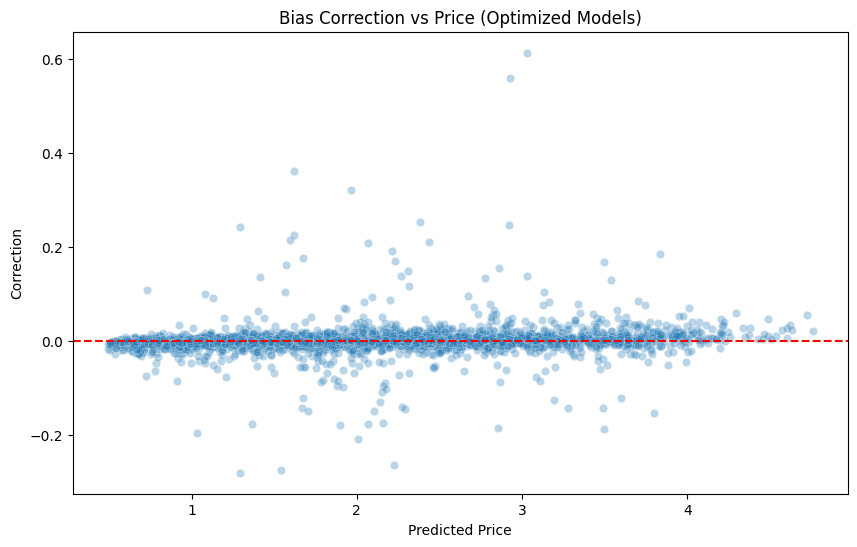

In [8]:
# ---------------------------------------------------------
# 6. ADDING THE RESIDUAL CORRECTOR (Residual Learning)
# ---------------------------------------------------------
print("\n6. Training Residual Corrector...")

class ResidualCorrectedMoE(BaseEstimator, RegressorMixin):
    def __init__(self, base_moe_model, corrector_model=None):
        self.base_moe_model = base_moe_model
        # We use a lightweight CatBoost as the corrector
        self.corrector_model = corrector_model if corrector_model else CatBoostRegressor(
            iterations=500,          
            depth=6, 
            learning_rate=0.03,
            l2_leaf_reg=5,           
            task_type='CPU', 
            devices='0',
            verbose=0,
            allow_writing_files=False,
            random_state=42
        )
        
    def fit(self, X, y):
        
        # 2. Generate OOF predictions to compute honest residuals
        print("   -> Computing OOF residuals (this may take time)...")
        oof_preds = cross_val_predict(self.base_moe_model, X, y, cv=5, n_jobs=1)
        
        # 3. Compute the Error
        residuals = y - oof_preds
        
        print(f"      Residual Mean: {residuals.mean():.4f}")
        print(f"      Residual Std Dev: {residuals.std():.4f}")
        
        # 4. Train the Corrector
        print("   -> Training the Corrector...")
        self.corrector_model.fit(X, residuals)
        return self

    def predict(self, X):
        base_pred = self.base_moe_model.predict(X)
        correction = self.corrector_model.predict(X)
        return base_pred + (1.0 * correction)

# Final Construction
# Note: we pass the already trained moe_model, but the ResidualCorrectedMoE class
# will use cross_val_predict which internally clones and fits on folds.
final_system = ResidualCorrectedMoE(base_moe_model=moe_model)
final_system.fit(X_train, y_train)

# Evaluation
y_pred_corrected = final_system.predict(X_test)

final_rmse_corr = np.sqrt(mean_squared_error(y_test, y_pred_corrected))
final_r2_corr = r2_score(y_test, y_pred_corrected)

print(f"\n==========================================")
print(f" FINAL OPTIMIZED RESULTS")
print(f"==========================================")
print(f" RMSE: {final_rmse_corr:.5f}")
print(f" R^2 : {final_r2_corr:.5f}")
print(f"==========================================")

# Quick plot
corrections_test = final_system.corrector_model.predict(X_test)
base_preds_test = final_system.base_moe_model.predict(X_test)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=base_preds_test, y=corrections_test, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.title("Bias Correction vs Price (Optimized Models)")
plt.xlabel("Predicted Price")
plt.ylabel("Correction")
plt.show()